# 🧠🤖 第1周·Day 4 | 复习日（Transformer深入理解）

> 🔄 复习 Day 1-2 核心概念 + 代码回顾 + 补漏练习

---

## 📝 复习要点

| Day | 主题 | 核心内容 |
|-----|------|----------|
| Day 1 | 自注意力机制 | Q/K/V 矩阵，Attention(Q,K,V) = softmax(QK^T/√d_k)V |
| Day 2 | Multi-Head Attention + 位置编码 | 多头并行捕捉不同语义关系；正弦/学习式位置编码 |

## 🧠 知识脉络

**自注意力** → 让每个词"看"其他所有词，决定关注谁 →
**多头注意力** → 多个"视角"并行观察（语法、语义、指代...）→
**位置编码** → 因为注意力本身没有位置信息，需要额外注入顺序

三者串联，构成了 Transformer 理解文本关系的基础。

## 💻 代码回顾：自注意力完整流程

用一句话 "我 爱 AI" 跑一遍完整的自注意力计算：

In [1]:
import numpy as np

np.random.seed(42)

# 输入: "我 爱 AI" —— 3个词，每个词4维向量
X = np.array([
    [1.0, 0.0, 0.0, 0.0],   # "我"
    [0.0, 1.0, 0.0, 0.0],   # "爱"
    [0.0, 0.0, 1.0, 0.0],   # "AI"
])

d_model = 4

# 随机生成权重矩阵（实际中是训练出来的）
W_q = np.random.randn(d_model, d_model)
W_k = np.random.randn(d_model, d_model)
W_v = np.random.randn(d_model, d_model)

# 计算 Q, K, V
Q = X @ W_q
K = X @ W_k
V = X @ W_v

print(f"输入 shape: {X.shape}")
print(f"Q shape: {Q.shape}, K shape: {K.shape}, V shape: {V.shape}")

输入 shape: (3, 4)
Q shape: (3, 4), K shape: (3, 4), V shape: (3, 4)


In [2]:
# 计算注意力分数 → 缩放 → softmax → 加权求和

def softmax(x):
    x_shifted = x - x.max(axis=-1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

scores = Q @ K.T
d_k = d_model
scaled_scores = scores / np.sqrt(d_k)
attn_weights = softmax(scaled_scores)
output = attn_weights @ V

print("注意力权重矩阵（每行代表一个词对其他词的关注度）:")
print(np.round(attn_weights, 3))
print(f"\n最终输出 shape: {output.shape}")
print("\n输出:")
print(np.round(output, 3))

注意力权重矩阵（每行代表一个词对其他词的关注度）:
[[0.13  0.338 0.532]
 [0.232 0.398 0.369]
 [0.506 0.195 0.299]]

最终输出 shape: (3, 4)

输出:
[[ 0.462 -0.708 -0.404 -0.252]
 [ 0.353 -0.963 -0.38  -0.317]
 [ 0.255 -0.866  0.122 -0.669]]


## 💻 代码回顾：多头注意力

对比单头 vs 多头的区别：

In [3]:
# 单头 vs 多头注意力对比

np.random.seed(42)
seq_len, d_model, num_heads = 3, 8, 2
d_k = d_model // num_heads

X = np.random.randn(seq_len, d_model)

# 单头
W_q = np.random.randn(d_model, d_model)
W_k = np.random.randn(d_model, d_model)
W_v = np.random.randn(d_model, d_model)
Q = X @ W_q; K = X @ W_k; V = X @ W_v
scores = (Q @ K.T) / np.sqrt(d_model)
single_attn = softmax(scores)

# 多头: 每个头只看一部分维度
Q_heads = np.hsplit(Q, num_heads)  # [head1(d_k), head2(d_k)]
K_heads = np.hsplit(K, num_heads)
V_heads = np.hsplit(V, num_heads)

multi_outputs = []
for i in range(num_heads):
    s = (Q_heads[i] @ K_heads[i].T) / np.sqrt(d_k)
    a = softmax(s)
    out = a @ V_heads[i]
    multi_outputs.append(out)

print("单头注意力权重:")
print(np.round(single_attn, 3))
print(f"\n多头 - 头1注意力权重:")
print(np.round(softmax((Q_heads[0] @ K_heads[0].T) / np.sqrt(d_k)), 3))
print(f"\n多头 - 头2注意力权重:")
print(np.round(softmax((Q_heads[1] @ K_heads[1].T) / np.sqrt(d_k)), 3))
print(f"\n💡 两个头关注的角度不同！拼接后信息更丰富")

单头注意力权重:
[[0.012 0.984 0.004]
 [0.    0.    1.   ]
 [0.145 0.765 0.09 ]]

多头 - 头1注意力权重:
[[0.516 0.425 0.058]
 [0.    0.    1.   ]
 [0.829 0.171 0.   ]]

多头 - 头2注意力权重:
[[0.002 0.996 0.003]
 [0.015 0.    0.985]
 [0.001 0.053 0.946]]

💡 两个头关注的角度不同！拼接后信息更丰富


/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 46 (.) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 55 (7) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_29441/1313444534.py:21: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallb

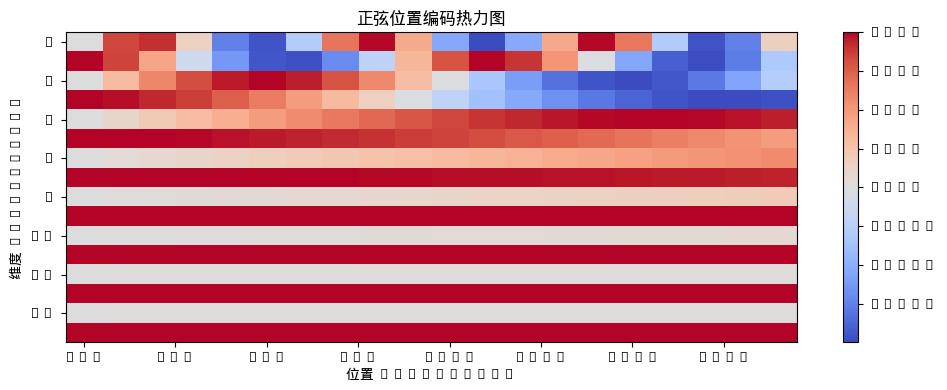

💡 每一行代表一个位置，每一列代表一个维度
💡 每个位置的编码都是唯一的，模型借此区分词的顺序


In [4]:
# 位置编码可视化
import matplotlib.pyplot as plt
import math

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Droid Sans Fallback', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

max_len, d_model = 20, 16
pe = np.zeros((max_len, d_model))
pos = np.arange(max_len).reshape(-1, 1)
dim = np.arange(d_model).reshape(1, -1)
pe[:, 0::2] = np.sin(pos / 10000 ** (dim[:, 0::2] / d_model))
pe[:, 1::2] = np.cos(pos / 10000 ** (dim[:, 1::2] / d_model))

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pe.T, aspect='auto', cmap='coolwarm')
ax.set_xlabel('位置 (Position)')
ax.set_ylabel('维度 (Dimension)')
ax.set_title('正弦位置编码热力图')
plt.colorbar(im)
plt.tight_layout()
plt.show()

print("💡 每一行代表一个位置，每一列代表一个维度")
print("💡 每个位置的编码都是唯一的，模型借此区分词的顺序")

## 📐 核心公式

- **Attention(Q,K,V)** = softmax(QK^T / √d_k) · V
- **Multi-Head** = Concat(head_1, ..., head_h) · W^O
- **位置编码**: PE(pos, 2i) = sin(pos / 10000^(2i/d)), PE(pos, 2i+1) = cos(pos / 10000^(2i/d))

## 🧩 查漏补缺测试

1. 自注意力中为什么要除以 √d_k？
2. 位置编码为什么要加到 Embedding 上？不用加法可以吗？
3. 多头注意力比单头好在哪里？头数越多越好吗？
4. Q、K、V 三个矩阵如果完全相同会怎样？
5. 如果句子长度翻倍，自注意力的计算量会变成多少倍？

## 💡 知识卡片

- **自注意力** = 每个词主动"看"其他所有词，决定关注谁
- **多头** = 多个"视角"并行观察（语法、语义、指代...）
- **位置编码** = 给每个位置一个"身份证"，让模型知道词的顺序
- **softmax** = 把分数变成概率分布，所有权重加起来等于1

## 👀 下周预告：第2周（Transformer深入理解·续）

- Day 1: FFN、LayerNorm 与残差连接
- Day 2: Tokenizer 与词嵌入
- Day 3: 整体架构回顾（GPT vs BERT）

💡 继续补完 Transformer 剩余组件，为后续训练篇章打基础！